In [22]:
import os
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, StratifiedGroupKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
import matplotlib.pyplot as plt

In [23]:

def lire_base_met(methode):
    X = []
    y = []
    chemin_dossier="./BDshape/"
    for fichier in sorted(os.listdir(chemin_dossier)):
        if not fichier.lower().endswith(methode.lower()):
            continue
        if not fichier.lower().startswith("s"):
            continue
        
        # Normalisation du nom : on met tout en majuscules
        fichier_upper = fichier.upper()
        
        try:
            classe = int(fichier_upper[1:3])  # Sxx
        except ValueError:
            continue  # Ignore les fichiers non conformes

        chemin_fichier = os.path.join(chemin_dossier, fichier)
        with open(chemin_fichier, "r") as f:
            contenu = f.read().strip()
            valeurs = np.fromstring(contenu, sep=" ")
            X.append(valeurs)
            y.append(classe)

    return np.array(X), np.array(y)


In [24]:

"""
    Cette fonction cherche le meilleur k pour k-NN avec 
    validation croisée.
    Trace le graphique des performences par nombre de voisins
    Retourne le k optimal.
"""
def trouver_meilleur_k(X_train, y_train):
    # Normalisation des données 
    scaler = StandardScaler()
    X_train_norm = scaler.fit_transform(X_train)
    meilleur_k = 1
    meilleurScore = -1
    accs = []
    for k in range(1, 16):
        model = KNeighborsClassifier(n_neighbors=k)
        scores = cross_val_score(model, X_train_norm, y_train, cv=5)
        acc = scores.mean()
        accs.append(acc)
        plt.plot(accs)
        plt.xlabel("Nombre de voisins")
        plt.ylabel("Performances")
        plt.title("Graphe des performences par nombre de voisins")
        if acc > meilleurScore:
            meilleurScore = acc
    return meilleur_k   

In [25]:

"""
    Cette fonction entraîne le KNN avec le k fourni et retourne 
    le modèle + données normalisées.
"""
def entrainer_knn(X_train, y_train, X_test, k):
    scaler = StandardScaler()
    X_train_norm = scaler.fit_transform(X_train)
    X_test_norm = scaler.transform(X_test)

    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_norm, y_train)

    return model, X_train_norm, X_test_norm


In [26]:

methode = input("Donner une méthode")
X, y = lire_base_met(methode)
print("Dimensions :", X.shape)

Donner une méthode SA


Dimensions : (99, 90)


In [27]:
# Division des données 70% entrainement et 30% test 
'''
random_state => assure une division toujours identique
stratify => garantit que toutes les classes sont représentées dans train ET test
'''
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3, 
    random_state=0, 
    stratify=y
)

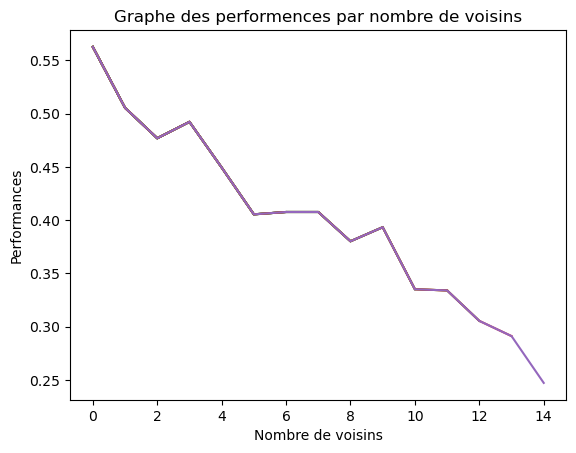

In [28]:
k= trouver_meilleur_k(X_train, y_train)

In [29]:
model, X_train_norm, X_test_norm = entrainer_knn(X_train, y_train, X_test, k)

In [30]:

# prédiction
y_pred = model.predict(X_test_norm)
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

print("="*50)
# Matrice de confusion
print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred))

print("="*50)
# Rapport complet (Precision, Recall, F1 pour chaque classe)
print("Rapport de classification :")
print(classification_report(y_test, y_pred))
print("="*50)

Accuracy: 0.77
Matrice de confusion :
[[4 0 0 0 0 0 0 0 0]
 [2 1 0 0 0 0 0 0 0]
 [0 0 3 0 0 0 0 0 0]
 [0 0 0 4 0 0 0 0 0]
 [1 0 0 0 2 0 0 0 0]
 [0 0 0 0 0 4 0 0 0]
 [0 0 0 0 1 0 2 0 0]
 [1 0 0 0 0 0 0 2 0]
 [0 1 0 0 0 0 0 1 1]]
Rapport de classification :
              precision    recall  f1-score   support

           1       0.50      1.00      0.67         4
           2       0.50      0.33      0.40         3
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         4
           5       0.67      0.67      0.67         3
           6       1.00      1.00      1.00         4
           7       1.00      0.67      0.80         3
           8       0.67      0.67      0.67         3
           9       1.00      0.33      0.50         3

    accuracy                           0.77        30
   macro avg       0.81      0.74      0.74        30
weighted avg       0.82      0.77      0.76        30

